# 02 — CRS, Projection, Distance, Area & Map Scale
## ระบบพิกัด เส้นโครงแผนที่ ระยะทาง พื้นที่ และมาตราส่วนแผนที่

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Beginner → Intermediate  
**ข้อมูล:** World Countries + Thailand ADM1 Provinces  
**เครื่องมือ:** GeoPandas · PyProj · Matplotlib · Folium

Notebook นี้ต่อจาก Notebook 01 โดยตอบคำถามสำคัญว่า

> **แผนที่ดูถูกต้องแล้ว แต่เราสามารถใช้พิกัดนั้นวัดระยะทาง พื้นที่ และทำ buffer ได้อย่างถูกต้องหรือยัง?**

แนวคิดหลัก:

$$
\text{CRS}
\rightarrow
\text{Projection}
\rightarrow
\text{Units}
\rightarrow
\text{Distortion}
\rightarrow
\text{Distance}
\rightarrow
\text{Area}
\rightarrow
\text{Scale}
\rightarrow
\text{Choose the right CRS}
$$

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. อธิบายความแตกต่างระหว่าง **Geographic CRS** และ **Projected CRS**
2. อธิบายความหมายของ EPSG code และหน่วยของพิกัด
3. แยกความแตกต่างระหว่าง `set_crs()` และ `to_crs()`
4. อธิบายว่า projection ทำให้ shape, area, distance หรือ direction บิดเบือนได้อย่างไร
5. อธิบายได้ว่าเหตุใด degree จึงไม่ใช่หน่วยระยะทางคงที่
6. เปรียบเทียบ geodesic distance กับ projected distance
7. คำนวณพื้นที่ด้วย CRS ที่เหมาะสม
8. อธิบายความแตกต่างระหว่าง map scale, scale bar และ DPI
9. เลือก CRS ให้เหมาะกับคำถามเชิงพื้นที่
10. Reproject จังหวัดพิษณุโลกเป็น **WGS 84 / UTM Zone 47N (EPSG:32647)** เพื่อวัดพื้นที่และสร้างแผนที่

## 1. Recap จาก Notebook 01

Notebook 01 ทำให้เราเข้าใจว่า

$$
GeoDataFrame = DataFrame + Geometry + CRS
$$

และ workflow เบื้องต้นคือ

$$
\text{Inspect}
\rightarrow
\text{Query}
\rightarrow
\text{Map}
\rightarrow
\text{Export}
$$

แต่เรายัง **จงใจไม่คำนวณพื้นที่ ระยะทาง หรือ buffer** เพราะต้องเข้าใจ CRS ก่อน

## 2. คำถามเปิดบท

สมมติว่า layer แสดงถูกตำแหน่งบนแผนที่โลก และมี CRS เป็น EPSG:4326

ถ้าเราสั่ง

```python
gdf.area
gdf.length
gdf.buffer(20000)
```

Python อาจรันคำสั่งได้ แต่คำตอบจะมีความหมายทางภูมิศาสตร์ถูกต้องหรือไม่?

หลักที่ต้องจำ:

$$
\boxed{
\text{Correct-looking geometry}
\not\Rightarrow
\text{correct measurement}
}
$$

ก่อนวัดอะไร ต้องถามก่อนว่า

```text
พิกัดคืออะไร?
↓
CRS คืออะไร?
↓
หน่วยคืออะไร?
↓
เหมาะกับ measurement ที่เราต้องการหรือไม่?
```

## 3. เตรียม libraries

Notebook นี้ใช้ libraries จาก 01 เพิ่มเติมเล็กน้อยคือ `pyproj` และ `xyzservices`

In [1]:
%pip -q install geopandas folium xyzservices pyogrio

In [2]:
from pathlib import Path
import shutil
import zipfile

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import folium
import xyzservices.providers as xyz

from shapely.geometry import Point
from pyproj import CRS, Geod
from IPython.display import display

print("GeoPandas:", gpd.__version__)
print("Pandas   :", pd.__version__)
print("Folium   :", folium.__version__)

GeoPandas: 1.2.0
Pandas   : 2.2.3
Folium   : 0.20.0


## 4. ตั้งค่า Font ภาษาไทย

ใช้ **Sarabun** จาก Google Fonts โดยดาวน์โหลดไฟล์ `.ttf` โดยตรง  
วิธีนี้เหมาะกับ Colab และไม่ต้องติดตั้ง font ผ่าน Ubuntu package repository

In [3]:
FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    response = requests.get(FONT_URL, timeout=60)
    response.raise_for_status()
    FONT_FILE.write_bytes(response.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))

font_name = mpl.font_manager.FontProperties(
    fname=str(FONT_FILE)
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

Thai font ready: Sarabun


## 5. สร้างพื้นที่ทำงาน

In [4]:
DATA_DIR = Path("/content/gis02_data")
OUTPUT_DIR = Path("/content/gis02_outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder   :", DATA_DIR)
print("Output folder :", OUTPUT_DIR)

Data folder   : /content/gis02_data
Output folder : /content/gis02_outputs


## 6. Helper function สำหรับดาวน์โหลด ZIP จาก GitHub

เราจะใช้ function เดิมซ้ำกับทั้ง World Countries และ Thailand ADM1

In [5]:
def download_and_extract_zip(url, zip_name, extract_name):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        zip_path.write_bytes(response.content)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    shp_files = list(extract_dir.rglob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(
            f"ไม่พบ .shp ใน {zip_name}"
        )

    print("ZIP      :", zip_path)
    print("Extracted:", extract_dir)
    print("Shapefile:", shp_files[0])

    return shp_files[0]

## 7. โหลด World Countries อีกครั้ง

เราใช้ dataset เดิมจาก Notebook 01 เพื่อให้เห็นว่า **ข้อมูลเดียวกัน** สามารถให้ผลต่างกันเมื่อเปลี่ยน projection

In [6]:
WORLD_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/world_map/World_Countries.zip"
)

world_shp = download_and_extract_zip(
    WORLD_URL,
    "World_Countries.zip",
    "World_Countries"
)

world = gpd.read_file(world_shp)

print("Features:", len(world))
print("CRS     :", world.crs)
display(world.head())

ZIP      : /content/gis02_data/World_Countries.zip
Extracted: /content/gis02_data/World_Countries
Shapefile: /content/gis02_data/World_Countries/World_Countries.shp
Features: 251
CRS     : EPSG:4326


,COUNTRY,ISO,COUNTRYAFF,AFF_ISO,geometry
0,Afghanistan,AF,Afghanistan,AF,"POLYGON ((61.27655 35.60725, 61.37505 35.6361,..."
1,Albania,AL,Albania,AL,"POLYGON ((19.36777 41.849, 19.34333 41.9125, 1..."
2,Algeria,DZ,Algeria,DZ,"POLYGON ((8.62203 36.94136, 8.63805 36.83111, ..."
3,American Samoa,AS,United States,US,None
4,Andorra,AD,Andorra,AD,"POLYGON ((1.44584 42.60194, 1.55972 42.65596, ..."


## 8. GIS Quality Control ก่อน projection

จาก Notebook 01 เราพบว่ามีบาง records ที่ geometry หาย  
เราจะรายงานจำนวนก่อน แล้วสร้าง layer ใหม่ที่มี geometry พร้อมสำหรับการวิเคราะห์

In [7]:
qc = pd.DataFrame({
    "Count": [
        len(world),
        world.geometry.isna().sum(),
        world.geometry.is_empty.sum(),
        (~world.is_valid.fillna(False)).sum()
    ]
}, index=[
    "All records",
    "Missing geometry",
    "Empty geometry",
    "Invalid / unavailable geometry"
])

display(qc)

,Count
All records,251
Missing geometry,35
Empty geometry,0
Invalid / unavailable geometry,47


In [8]:
world_valid = world[
    world.geometry.notna()
    & ~world.geometry.is_empty
].copy()

print("Original records :", len(world))
print("Usable geometries:", len(world_valid))

Original records : 251
Usable geometries: 216


# Part A — Coordinate Reference System

## 9. CRS คืออะไร?

CRS บอกว่าเลขพิกัดที่อยู่ใน geometry หมายความว่าอะไร

CRS โดยแนวคิดประกอบด้วย

```text
Reference surface / datum
+
Coordinate system
+
Units
+
Projection (ถ้าเป็น projected CRS)
```

ถ้าเป็น Geographic CRS เรามักเขียนตำแหน่งด้วย

$$
(\lambda,\phi)
$$

โดย

- $\lambda$ = longitude
- $\phi$ = latitude

ถ้าเป็น Projected CRS เราใช้พิกัดเชิงระนาบ

$$
(x,y)
$$

ซึ่งมักมีหน่วยเป็น meter

In [9]:
print(world_valid.crs)

world_crs = CRS.from_user_input(world_valid.crs)

print("\nCRS name       :", world_crs.name)
print("Is geographic  :", world_crs.is_geographic)
print("Is projected   :", world_crs.is_projected)

print("\nAxis information:")
for axis in world_crs.axis_info:
    print(
        axis.name,
        "| unit =", axis.unit_name
    )

EPSG:4326

CRS name       : WGS 84
Is geographic  : True
Is projected   : False

Axis information:
Geodetic latitude | unit = degree
Geodetic longitude | unit = degree


## 10. Geographic CRS vs Projected CRS

| Geographic CRS | Projected CRS |
|---|---|
| Longitude / Latitude | X / Y |
| พื้นผิวโค้งของโลก | ระนาบแผนที่ |
| หน่วยมักเป็น degree | หน่วยมักเป็น meter |
| เหมาะกับตำแหน่ง / interchange | เหมาะกับ measurement เมื่อเลือก projection ถูกต้อง |
| ตัวอย่าง EPSG:4326 | ตัวอย่าง EPSG:32647 |

> **Projected CRS ไม่ได้แปลว่าเหมาะกับทุกการวิเคราะห์**  
> ต้องเลือก projection ให้ตรงกับคำถาม

## 11. EPSG code ที่จะใช้ในบทนี้

### EPSG:4326 — WGS 84
- Longitude / Latitude
- Geographic CRS
- เหมาะกับการเก็บพิกัดและการแลกเปลี่ยนข้อมูล

### EPSG:3857 — Web Mercator
- ใช้แพร่หลายใน web maps
- หน่วย coordinate เป็น meter
- **ไม่ควรใช้เพื่อเปรียบเทียบพื้นที่**

### EPSG:6933 — Global Equal Area
- Equal-area projection ระดับโลก
- เหมาะกับการเปรียบเทียบพื้นที่ระหว่างประเทศ

### EPSG:32647 — WGS 84 / UTM Zone 47N
- หน่วย meter
- เหมาะกับ local analysis บริเวณพิษณุโลกและพื้นที่ใน UTM Zone 47N

In [10]:
crs_codes = [
    "EPSG:4326",
    "EPSG:3857",
    "EPSG:6933",
    "EPSG:32647"
]

rows = []

for code_value in crs_codes:
    c = CRS.from_user_input(code_value)

    rows.append({
        "CRS": code_value,
        "Name": c.name,
        "Geographic": c.is_geographic,
        "Projected": c.is_projected,
        "Axis units": ", ".join(
            sorted({
                axis.unit_name
                for axis in c.axis_info
            })
        )
    })

crs_table = pd.DataFrame(rows)
display(crs_table)

,CRS,Name,Geographic,Projected,Axis units
0,EPSG:4326,WGS 84,True,False,degree
1,EPSG:3857,WGS 84 / Pseudo-Mercator,False,True,metre
2,EPSG:6933,WGS 84 / NSIDC EASE-Grid 2.0 Global,False,True,metre
3,EPSG:32647,WGS 84 / UTM zone 47N,False,True,metre


# Part B — `set_crs()` vs `to_crs()`

## 12. ความแตกต่างที่สำคัญมาก

### `set_crs()`

ใช้เมื่อเรารู้ว่า coordinate numbers ปัจจุบัน **เป็น CRS อะไรอยู่แล้ว**

มันเป็นการ “กำหนด/ติด label CRS”

$$
\text{coordinates stay the same}
$$

### `to_crs()`

ใช้เมื่อเราต้องการ **reproject** พิกัดไปยัง CRS ใหม่

$$
(\lambda,\phi)
\xrightarrow{\text{projection}}
(x,y)
$$

> **อย่าใช้ `set_crs()` เพื่อแปลงเส้นโครงแผนที่**

In [11]:
def find_column(gdf, candidates, required=False):
    lookup = {
        str(c).upper(): c
        for c in gdf.columns
    }

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError(
            "ไม่พบ field ที่ต้องการ\n"
            + "Fields จริง: "
            + ", ".join(map(str, gdf.columns))
        )

    return None


country_col = find_column(
    world_valid,
    ["COUNTRY", "NAME", "ADMIN", "COUNTRYAFF"],
    required=True
)

thailand = world_valid[
    world_valid[country_col]
        .astype(str)
        .str.strip()
        .str.casefold()
    == "thailand"
].copy()

print("Country field:", country_col)
print("Thailand features:", len(thailand))

Country field: COUNTRY
Thailand features: 1


In [12]:
print("Thailand in original CRS")
print("CRS:", thailand.crs)
print("Bounds:")
print(thailand.total_bounds)

Thailand in original CRS
CRS: EPSG:4326
Bounds:
[ 97.44664512   5.63347307 105.63929131  20.45458213]


In [13]:
thailand_mercator = thailand.to_crs("EPSG:3857")

print("Thailand after to_crs('EPSG:3857')")
print("CRS:", thailand_mercator.crs)
print("Bounds:")
print(thailand_mercator.total_bounds)

Thailand after to_crs('EPSG:3857')
CRS: EPSG:3857
Bounds:
[10847710.91398445   628128.22631153 11759712.11664766  2326960.89195173]


### ทดลองสิ่งที่ “ผิด” อย่างตั้งใจ

เราจะสร้าง copy แล้วใช้ `set_crs(..., allow_override=True)` เพื่อดูว่าเกิดอะไรขึ้น

> อย่าใช้ผลลัพธ์ `wrong_crs_example` ในงานจริง

In [14]:
wrong_crs_example = thailand.copy()

wrong_crs_example = wrong_crs_example.set_crs(
    "EPSG:3857",
    allow_override=True
)

print("Original coordinates:")
print(thailand.total_bounds)

print("\nAfter WRONG set_crs:")
print(wrong_crs_example.total_bounds)

print("\nNotice: coordinate values did NOT change.")

Original coordinates:
[ 97.44664512   5.63347307 105.63929131  20.45458213]

After WRONG set_crs:
[ 97.44664512   5.63347307 105.63929131  20.45458213]

Notice: coordinate values did NOT change.


### Concept Check

สังเกตว่า

```text
to_crs()
→ coordinate values เปลี่ยน

set_crs()
→ coordinate values ไม่เปลี่ยน
```

ดังนั้น

> `set_crs()` = บอกความหมายของเลขพิกัด  
> `to_crs()` = คำนวณเลขพิกัดชุดใหม่

# Part C — Map Projection & Distortion

## 13. ทำไมโลกกลมจึงเกิด distortion เมื่อทำแผนที่แบน?

เมื่อเราแปลงพื้นผิวโค้งของโลกลงบนระนาบ จะไม่สามารถรักษาทุกคุณสมบัติให้ถูกต้องพร้อมกันทุกตำแหน่งได้

$$
\boxed{
\text{No flat map preserves}
\;
shape + area + distance + direction
\;
\text{everywhere}
}
$$

แนวคิด projection ที่ควรรู้:

- **Conformal** — รักษามุม/รูปร่างเฉพาะที่ได้ดี
- **Equal-area** — รักษาพื้นที่
- **Equidistant** — รักษาระยะทางบางทิศหรือจากบางจุด
- **Compromise** — พยายามลด distortion หลายชนิดให้ดูสมดุล

## 14. World map ใน EPSG:4326

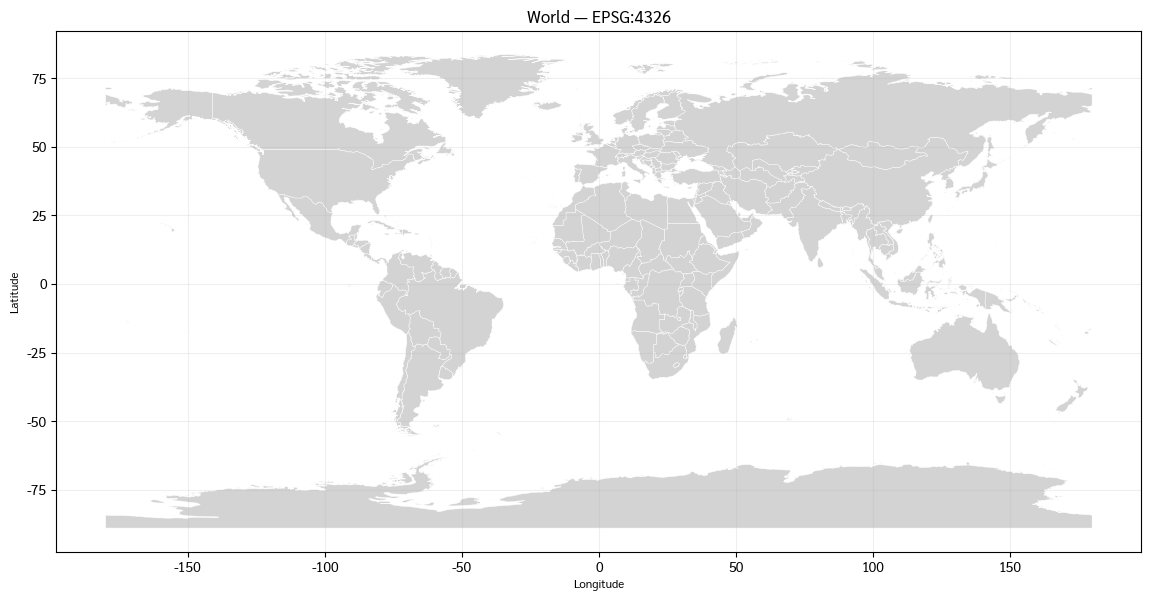

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

world_valid.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.3
)

ax.set_title("World — EPSG:4326")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)

plt.show()

## 15. World map ใน Web Mercator — EPSG:3857

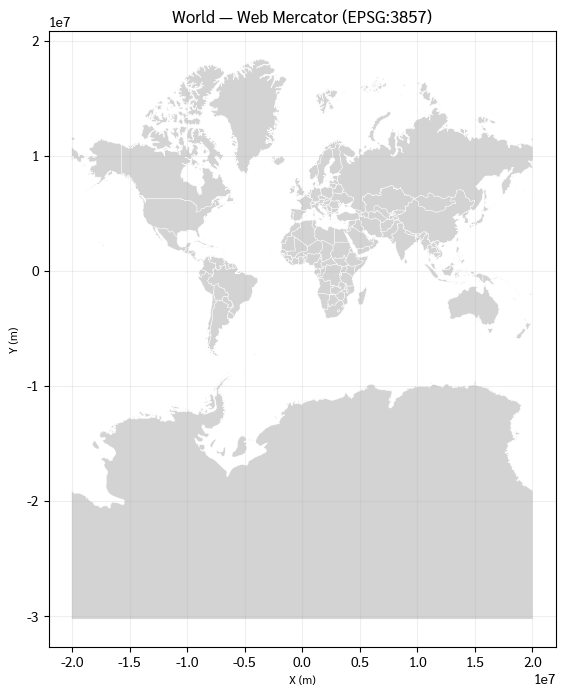

In [16]:
world_3857 = world_valid.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(14, 8))

world_3857.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.3
)

ax.set_title("World — Web Mercator (EPSG:3857)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.grid(alpha=0.2)

plt.show()

## 16. World map ใน Equal-area projection — EPSG:6933

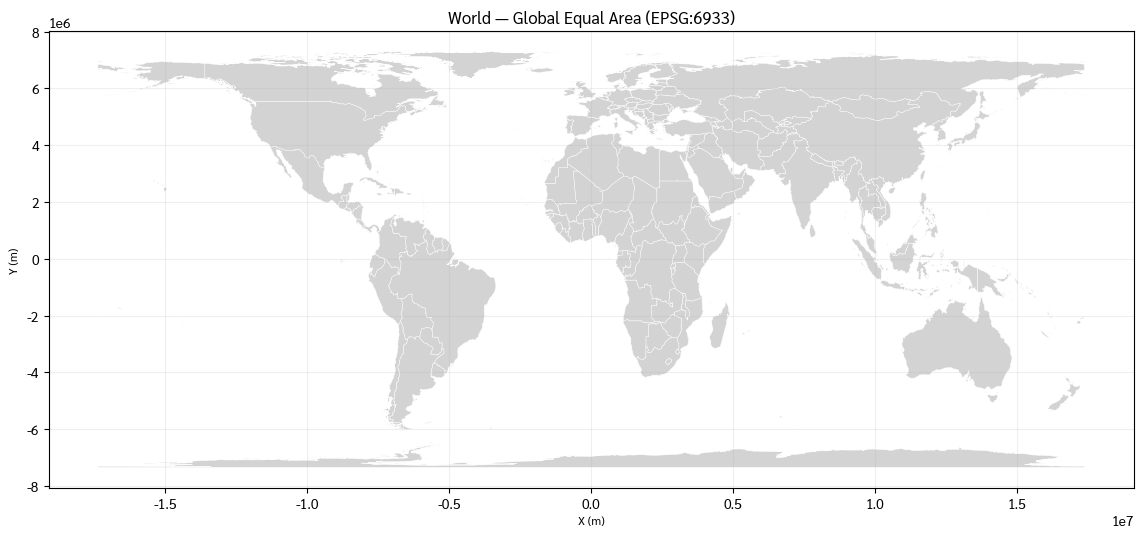

In [17]:
world_6933 = world_valid.to_crs("EPSG:6933")

fig, ax = plt.subplots(figsize=(14, 7))

world_6933.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.3
)

ax.set_title("World — Global Equal Area (EPSG:6933)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.grid(alpha=0.2)

plt.show()

### Observe before calculating

เปรียบเทียบ 3 แผนที่แล้วตอบ:

1. Greenland ดูมีขนาดสัมพันธ์กับ Africa เหมือนกันหรือไม่?
2. พื้นที่ใกล้ขั้วโลกเปลี่ยนมากกว่าพื้นที่ใกล้เส้นศูนย์สูตรหรือไม่?
3. แผนที่ที่ “ดูคุ้นตา” จำเป็นต้องรักษาพื้นที่จริงหรือไม่?

> รูปทรงที่เห็นบนแผนที่ไม่ใช่หลักฐานว่าการวัดพื้นที่จะถูกต้อง

# Part D — Degree ไม่ใช่ระยะทางคงที่

## 17. 1° longitude เท่ากับกี่กิโลเมตร?

ที่เส้นศูนย์สูตร longitude 1° มีระยะประมาณ 111 km  
แต่เมื่อขึ้นไปละติจูดสูงขึ้น เส้น longitude จะค่อย ๆ เข้าใกล้กัน

แนวคิดอย่างง่าย:

$$
d_{\lambda}
\approx
R\cos(\phi)\Delta\lambda
$$

โดย

- $R$ = รัศมีโลก
- $\phi$ = latitude
- $\Delta\lambda$ = longitude difference ในหน่วย radian

ดังนั้น

$$
\boxed{
degree \neq fixed\ distance
}
$$

In [18]:
geod = Geod(ellps="WGS84")

latitudes = [0, 15, 30, 45, 60]

records = []

for lat in latitudes:
    lon1 = 100.0
    lon2 = 101.0

    az12, az21, distance_m = geod.inv(
        lon1,
        lat,
        lon2,
        lat
    )

    records.append({
        "Latitude_deg": lat,
        "Distance_for_1deg_lon_km": distance_m / 1000
    })

lon_degree_table = pd.DataFrame(records)

display(
    lon_degree_table.round(2)
)

,Latitude_deg,Distance_for_1deg_lon_km
0,0,111.32
1,15,107.55
2,30,96.49
3,45,78.85
4,60,55.80


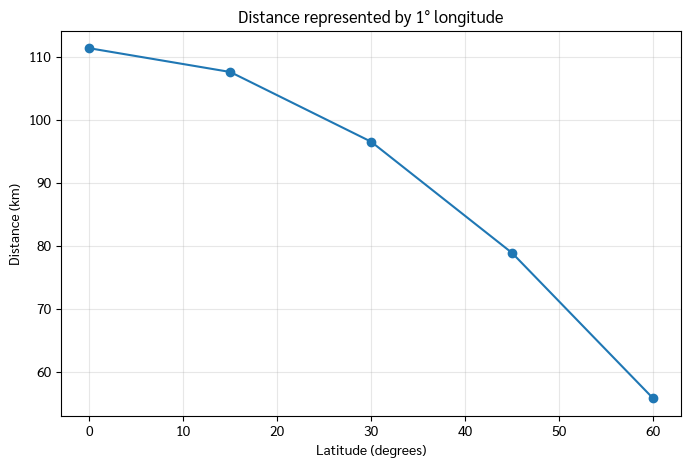

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    lon_degree_table["Latitude_deg"],
    lon_degree_table["Distance_for_1deg_lon_km"],
    marker="o"
)

ax.set_title("Distance represented by 1° longitude")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Distance (km)")
ax.grid(alpha=0.3)

plt.show()

### Interpretation

เมื่อ latitude เพิ่มขึ้น ระยะทางของ longitude 1° ลดลง

ดังนั้น coordinate difference เช่น

```text
Δlongitude = 1°
```

ไม่ได้แปลว่า ground distance เท่ากันทุกตำแหน่งบนโลก

นี่เป็นเหตุผลหนึ่งที่เราไม่ควรใช้ degree โดยตรงเพื่อแทน meter หรือ kilometer

# Part E — Distance: degree, geodesic และ projected distance

## 18. Euclidean distance

บนระนาบ เราคำนวณระยะทางได้จาก

$$
d=
\sqrt{
(x_2-x_1)^2+
(y_2-y_1)^2
}
$$

แต่สูตรนี้จะมีความหมายเชิงระยะทางก็ต่อเมื่อพิกัด $x,y$ อยู่ใน CRS ที่เหมาะสมและมีหน่วยเชิงเส้น

In [20]:
A = Point(100.0, 16.0)
B = Point(101.0, 16.0)

points_ll = gpd.GeoDataFrame(
    {
        "name": ["A", "B"],
        "geometry": [A, B]
    },
    crs="EPSG:4326"
)

points_ll

,name,geometry
0,A,POINT (100 16)
1,B,POINT (101 16)


## 19. วิธีที่ไม่ควรตีความเป็น kilometer

ถ้าใช้ `.distance()` บน EPSG:4326 ผลลัพธ์อยู่ในหน่วยพิกัดของ CRS ซึ่งคือ degree

In [21]:
degree_distance = points_ll.geometry.iloc[0].distance(
    points_ll.geometry.iloc[1]
)

print(
    "Planar distance in EPSG:4326 coordinate units:",
    degree_distance
)
print("This is NOT 1 kilometer.")

Planar distance in EPSG:4326 coordinate units: 1.0
This is NOT 1 kilometer.


## 20. Geodesic distance บน ellipsoid

`pyproj.Geod` คำนวณระยะทางตามผิว ellipsoid

In [22]:
_, _, geodesic_m = geod.inv(
    100.0, 16.0,
    101.0, 16.0
)

print(
    "Geodesic distance:",
    round(geodesic_m / 1000, 3),
    "km"
)

Geodesic distance: 107.034 km


## 21. Projected distance ด้วย UTM Zone 47N

บริเวณ longitude ประมาณ 100°E และ latitude 16°N อยู่ใน UTM Zone 47N  
เราจึงแปลงจุดเป็น EPSG:32647 แล้วคำนวณ Euclidean distance ในหน่วย meter

In [23]:
points_utm47 = points_ll.to_crs("EPSG:32647")

utm_distance_m = (
    points_utm47.geometry.iloc[0]
    .distance(
        points_utm47.geometry.iloc[1]
    )
)

print(
    "UTM distance:",
    round(utm_distance_m / 1000, 3),
    "km"
)

UTM distance: 107.027 km


In [24]:
distance_compare = pd.DataFrame({
    "Method": [
        "Raw coordinate difference",
        "Geodesic on WGS84",
        "UTM Zone 47N"
    ],
    "Value": [
        degree_distance,
        geodesic_m / 1000,
        utm_distance_m / 1000
    ],
    "Unit": [
        "degree",
        "km",
        "km"
    ]
})

display(distance_compare)

,Method,Value,Unit
0,Raw coordinate difference,1.000000,degree
1,Geodesic on WGS84,107.034282,km
2,UTM Zone 47N,107.026832,km


# Part F — Area & Projection

## 22. พื้นที่จาก polygon

ถ้า polygon อยู่ใน projected CRS ที่ใช้ meter:

$$
A_{km^2}
=
\frac{
A_{m^2}
}{
10^6
}
$$

แต่ถ้า polygon อยู่ใน EPSG:4326 แล้วสั่ง `.area` โดยตรง ผลลัพธ์ไม่ใช่ km²

ดังนั้น

$$
\boxed{
\text{Area calculation requires an appropriate CRS}
}
$$

In [25]:
# ทำเพื่อการสาธิตเท่านั้น
raw_area = thailand.area

print("Raw .area on EPSG:4326:")
print(raw_area.values)

print("\nCRS:", thailand.crs)
print(
    "Do NOT report this value as m² or km²."
)

Raw .area on EPSG:4326:
[43.05312454]

CRS: EPSG:4326
Do NOT report this value as m² or km².


/tmp/ipykernel_1837/3407606553.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raw_area = thailand.area


## 23. เปรียบเทียบ distortion ของพื้นที่

เราจะเลือกประเทศที่อยู่ต่าง latitude กันเพื่อดูว่า Web Mercator กับ Equal-area ให้พื้นที่ต่างกันอย่างไร

In [26]:
comparison_names = [
    "Thailand",
    "Canada",
    "Greenland"
]

name_text = (
    world_valid[country_col]
    .astype(str)
    .str.strip()
)

countries_compare = world_valid[
    name_text.isin(comparison_names)
].copy()

# ถ้าชื่อ Greenland ไม่ตรง exact ให้ลอง contains
if len(countries_compare) < 3:
    pattern = "|".join(comparison_names)

    countries_compare = world_valid[
        world_valid[country_col]
        .astype(str)
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
    ].copy()

display(
    countries_compare[
        [country_col, "geometry"]
    ]
)

,COUNTRY,geometry
41,Canada,"MULTIPOLYGON (((-67.20655 45.18304, -67.33868 ..."
90,Greenland,"MULTIPOLYGON (((-50.89805 68.66555, -50.90166 ..."
223,Thailand,"MULTIPOLYGON (((100.12711 6.42495, 100.09018 6..."


In [27]:
area_3857 = (
    countries_compare
    .to_crs("EPSG:3857")
    .area
    / 1_000_000
)

area_6933 = (
    countries_compare
    .to_crs("EPSG:6933")
    .area
    / 1_000_000
)

area_compare = pd.DataFrame({
    "Country": countries_compare[country_col].values,
    "Area_WebMercator_km2": area_3857.values,
    "Area_EqualArea_km2": area_6933.values
})

area_compare["Difference_pct"] = (
    (
        area_compare["Area_WebMercator_km2"]
        - area_compare["Area_EqualArea_km2"]
    )
    / area_compare["Area_EqualArea_km2"]
    * 100
)

display(
    area_compare.round(1)
)

,Country,Area_WebMercator_km2,Area_EqualArea_km2,Difference_pct
0,Canada,51288010.1,9961375.5,414.9
1,Greenland,35237051.9,2163415.6,1528.8
2,Thailand,553712.1,511195.8,8.3


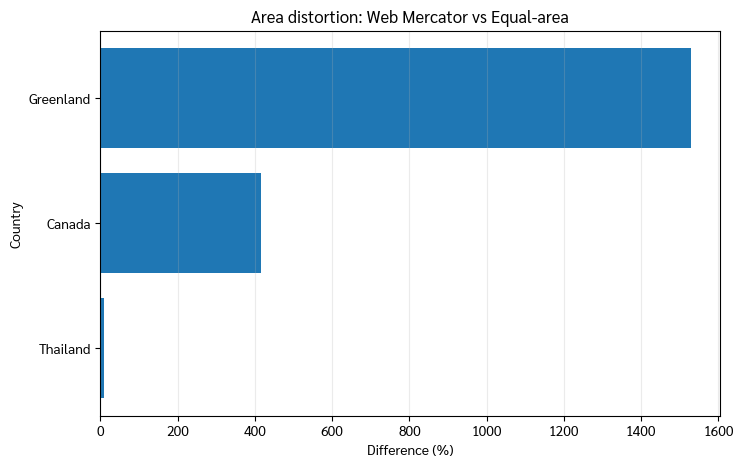

In [28]:
plot_data = area_compare.sort_values(
    "Difference_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_data["Country"],
    plot_data["Difference_pct"]
)

ax.set_title(
    "Area distortion: Web Mercator vs Equal-area"
)
ax.set_xlabel("Difference (%)")
ax.set_ylabel("Country")
ax.grid(
    axis="x",
    alpha=0.25
)

plt.show()

### Interpretation

`EPSG:3857` มีประโยชน์มากสำหรับ web mapping แต่ไม่ได้ถูกออกแบบเพื่อรักษาพื้นที่

ดังนั้น

```text
Web Mercator
→ good for web display
→ not for area comparison
```

ขณะที่ equal-area projection ถูกออกแบบให้พื้นที่บนแผนที่สัมพันธ์กับพื้นที่จริงอย่างสม่ำเสมอกว่า

> **CRS ที่เหมาะกับการแสดงผล ไม่จำเป็นต้องเหมาะกับการวิเคราะห์**

# Part G — Map Scale

## 24. Representative Fraction

มาตราส่วนตัวเลขเขียนเป็น

$$
1:n
$$

หมายความว่า

$$
D_{ground}
=
D_{map}\times n
$$

ตัวอย่าง

$$
1:50{,}000
$$

หมายถึง

$$
1\;cm
=
50{,}000\;cm
=
500\;m
$$

In [29]:
scale_denominator = 50_000
map_distance_cm = 4

ground_cm = (
    map_distance_cm
    * scale_denominator
)

ground_km = (
    ground_cm
    / 100_000
)

print(
    f"{map_distance_cm} cm on a 1:{scale_denominator:,} map"
)
print(
    f"= {ground_km:.2f} km on the ground"
)

4 cm on a 1:50,000 map
= 2.00 km on the ground


## 25. Numeric scale vs Graphic scale

### Numeric scale

```text
1 : 50,000
```

### Graphic scale

```text
0 ├────────┤ 5 km
```

ข้อดีของ graphic scale คือ ถ้ารูปถูก resize ทั้งแผนที่และ scale bar จะย่อ/ขยายไปพร้อมกัน

ขณะที่ numeric scale อาจไม่ถูกต้องอีกต่อไปถ้าขนาดรูปที่พิมพ์เปลี่ยน

## 26. DPI ไม่ใช่ Map Scale

$$
DPI=
\frac{
pixels
}{
inch
}
$$

เช่น `300 dpi` บอกความละเอียดของ output image

แต่ไม่ได้บอก

- ground distance
- map scale
- CRS
- spatial resolution

| Term | Meaning |
|---|---|
| Map scale | ระยะบนแผนที่เทียบกับระยะจริง |
| DPI | ความละเอียดของรูปภาพต่อ inch |
| CRS | ความหมายและระบบอ้างอิงของพิกัด |
| Spatial resolution | ขนาดรายละเอียดเชิงพื้นที่ของข้อมูล |

# Part H — เลือก CRS ตามคำถาม

## 27. Decision table

| งาน | CRS ที่เหมาะโดยแนวคิด |
|---|---|
| เก็บ/แลกเปลี่ยน Longitude-Latitude | EPSG:4326 |
| Folium / Web GIS | EPSG:4326 สำหรับ vector overlay |
| Web tile display | Web Mercator ecosystem |
| เปรียบเทียบพื้นที่ระดับโลก | Equal-area projection |
| ระยะทาง/Buffer บริเวณพิษณุโลก | EPSG:32647 |
| พื้นที่ระดับ local ในพิษณุโลก | EPSG:32647 |

หลักสำคัญ:

$$
oxed{
	ext{Choose CRS based on the spatial question}
}
$$

## 28. Analysis CRS vs Display CRS

การทำงาน GIS หนึ่งงานสามารถใช้หลาย CRS ได้

ตัวอย่าง:

```text
Analysis
EPSG:32647
meter
↓
calculate area / distance / buffer
↓
to_crs(EPSG:4326)
↓
Folium display
```

ดังนั้น

$$
\boxed{
Analysis\ CRS
\neq
Display\ CRS
}
$$

ในหลาย workflow นี่เป็นสิ่งปกติและถูกต้อง

# Part I — จากโลกสู่ประเทศไทย: จังหวัดพิษณุโลก

## 29. Download Thailand ADM1

ตอนนี้เราเริ่มใช้ข้อมูลจังหวัดจริงจาก repository เดียวกัน  
แต่ Notebook 02 จะใช้เพียง **จังหวัดพิษณุโลก** เพื่อสาธิต projection และ area

การวิเคราะห์ 77 จังหวัดอย่างเต็มรูปแบบจะอยู่ใน Notebook 03


### หมายเหตุสำคัญเรื่องภาษาไทยใน Shapefile

ถ้า `ADM1_TH` แสดงเป็นข้อความลักษณะ

```text
à¸...
```

ปัญหานี้ **ไม่ใช่ปัญหาฟอนต์** แต่เป็น **character encoding ของ DBF ถูกอ่านผิด**

- `Sarabun` / Matplotlib font มีหน้าที่ควบคุม *การวาดตัวอักษร*
- `encoding="UTF-8"` มีหน้าที่ควบคุม *การถอดรหัสข้อความจาก DBF*

ดังนั้นเราต้องอ่าน Shapefile ด้วย encoding ที่ถูกต้องตั้งแต่ต้น

```python
province = gpd.read_file(
    adm1_shp,
    encoding="UTF-8"
)
```

เมื่อ string ภาษาไทยถูกต้องแล้ว Browser/Colab table, Matplotlib และ Folium จึงจะแสดงชื่อไทยได้ถูกต้อง


In [30]:
ADM1_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm1/tha_adm1_province_shapefile.zip"
)

adm1_shp = download_and_extract_zip(
    ADM1_URL,
    "tha_adm1_province_shapefile.zip",
    "tha_adm1"
)

# IMPORTANT:
# ADM1_TH is stored as Thai UTF-8 text in the DBF.
# If encoding is not specified, GDAL/GeoPandas may guess incorrectly
# and Thai text can appear as mojibake such as "à¸...".
province = gpd.read_file(
    adm1_shp,
    encoding="UTF-8"
)

print("Features:", len(province))
print("CRS:", province.crs)
print("Columns:")
print(list(province.columns))

display(province.head())

ZIP      : /content/gis02_data/tha_adm1_province_shapefile.zip
Extracted: /content/gis02_data/tha_adm1
Shapefile: /content/gis02_data/tha_adm1/tha_adm1_province.shp
Features: 77
CRS: EPSG:4326
Columns:
['Shape_Leng', 'Shape_Area', 'ADM1_EN', 'ADM1_TH', 'ADM1_PCODE', 'ADM1_REF', 'ADM1ALT1EN', 'ADM1ALT2EN', 'ADM1ALT1TH', 'ADM1ALT2TH', 'ADM0_EN', 'ADM0_TH', 'ADM0_PCODE', 'date', 'validOn', 'validTo', 'geometry']


,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM1ALT1TH,ADM1ALT2TH,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
0,2.417227,0.131339,Bangkok,กรุงเทพมหานคร,TH10,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.91398 13.94655, 100.90848 13.902..."
1,1.695100,0.079262,Samut Prakan,สมุทรปราการ,TH11,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.86078 13.6969, 100.8774 13.68972..."
2,1.251111,0.053238,Nonthaburi,นนทบุรี,TH12,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.56748 13.95118, 100.54364 13.849..."
3,1.884945,0.126983,Pathum Thani,ปทุมธานี,TH13,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.95121 14.27166, 100.9497 14.2666..."
4,3.041716,0.213938,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา,TH14,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.60223 14.65499, 100.59705 14.650..."


In [31]:
# ตรวจว่าข้อความภาษาไทยถูกอ่านถูกต้องหรือไม่
if "ADM1_TH" in province.columns:
    print("ตัวอย่างชื่อจังหวัดภาษาไทย:")
    display(
        province[
            ["ADM1_EN", "ADM1_TH"]
        ].head(10)
    )
else:
    print("ไม่พบ field ADM1_TH — โปรดตรวจ schema ของข้อมูล")

ตัวอย่างชื่อจังหวัดภาษาไทย:


,ADM1_EN,ADM1_TH
0,Bangkok,กรุงเทพมหานคร
1,Samut Prakan,สมุทรปราการ
2,Nonthaburi,นนทบุรี
3,Pathum Thani,ปทุมธานี
4,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา
5,Ang Thong,อ่างทอง
6,Lop Buri,ลพบุรี
7,Sing Buri,สิงห์บุรี
8,Chai Nat,ชัยนาท
9,Saraburi,สระบุรี


In [32]:
province_qc = pd.DataFrame({
    "Count": [
        len(province),
        province.geometry.isna().sum(),
        province.geometry.is_empty.sum()
    ]
}, index=[
    "All province records",
    "Missing geometry",
    "Empty geometry"
])

display(province_qc)

,Count
All province records,77
Missing geometry,0
Empty geometry,0


## 30. ตรวจ field จังหวัดก่อน query

เราจะไม่ hard-code ชื่อ column โดยไม่ตรวจ schema

In [33]:
adm1_th_col = find_column(
    province,
    ["ADM1_TH", "NAME_1_TH", "PROV_TH"],
    required=False
)

adm1_en_col = find_column(
    province,
    ["ADM1_EN", "NAME_1", "PROV_EN", "ADM1_PCODE"],
    required=False
)

print("Thai province field   :", adm1_th_col)
print("English province field:", adm1_en_col)

if adm1_th_col:
    display(
        province[
            [adm1_th_col, "geometry"]
        ].head()
    )

Thai province field   : ADM1_TH
English province field: ADM1_EN


,ADM1_TH,geometry
0,กรุงเทพมหานคร,"POLYGON ((100.91398 13.94655, 100.90848 13.902..."
1,สมุทรปราการ,"POLYGON ((100.86078 13.6969, 100.8774 13.68972..."
2,นนทบุรี,"POLYGON ((100.56748 13.95118, 100.54364 13.849..."
3,ปทุมธานี,"POLYGON ((100.95121 14.27166, 100.9497 14.2666..."
4,พระนครศรีอยุธยา,"POLYGON ((100.60223 14.65499, 100.59705 14.650..."


## 31. Query จังหวัดพิษณุโลก

ถ้ามี `ADM1_TH` จะใช้ชื่อภาษาไทยโดยตรง  
ถ้า schema ต่างออกไป code จะพยายามค้นจาก field ภาษาอังกฤษ

In [34]:
phs = province.iloc[0:0].copy()

if adm1_th_col:
    phs = province[
        province[adm1_th_col]
        .astype(str)
        .str.contains(
            "พิษณุโลก",
            na=False
        )
    ].copy()

if phs.empty and adm1_en_col:
    phs = province[
        province[adm1_en_col]
        .astype(str)
        .str.contains(
            "Phitsanulok",
            case=False,
            na=False
        )
    ].copy()

if phs.empty:
    raise ValueError(
        "ไม่พบจังหวัดพิษณุโลก "
        "โปรดตรวจชื่อจังหวัดจาก attributes จริง"
    )

print("Phitsanulok features:", len(phs))
print("Original CRS:", phs.crs)

display(phs)

Phitsanulok features: 1
Original CRS: EPSG:4326


,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM1ALT1TH,ADM1ALT2TH,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
52,7.34466,0.892881,Phitsanulok,พิษณุโลก,TH65,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.96783 17.57164, 100.96502 17.574..."


## 32. ทำไมพิษณุโลกใช้ UTM Zone 47N?

UTM แบ่งโลกเป็น zone ตาม longitude โดยแต่ละ zone กว้างประมาณ 6°

สูตรหา zone โดยประมาณ:

$$
Zone
=
\left\lfloor
\frac{
\lambda+180
}{
6
}
\right\rfloor
+1
$$

สำหรับ longitude ประมาณ 100°E:

$$
Zone
\approx
47
$$

พิษณุโลกอยู่ซีกโลกเหนือ จึงใช้

```text
WGS 84 / UTM Zone 47N
EPSG:32647
```

In [35]:
phs_ll = phs.to_crs("EPSG:4326")

rep_point = (
    phs_ll.geometry
    .representative_point()
    .iloc[0]
)

longitude = rep_point.x
latitude = rep_point.y

utm_zone = int(
    np.floor(
        (longitude + 180) / 6
    ) + 1
)

print(
    "Representative longitude:",
    round(longitude, 4)
)
print(
    "Representative latitude :",
    round(latitude, 4)
)
print(
    "Estimated UTM zone      :",
    utm_zone
)

Representative longitude: 100.5381
Representative latitude : 17.0318
Estimated UTM zone      : 47


## 33. Reproject พิษณุโลกเป็น EPSG:32647

In [36]:
phs_utm = phs.to_crs("EPSG:32647")

print("CRS:", phs_utm.crs)
print("Bounds (meters):")
print(phs_utm.total_bounds)

CRS: EPSG:32647
Bounds (meters):
[ 590973.19645104 1804913.11094493  724366.21133633 1962937.9147609 ]


## 34. คำนวณพื้นที่จังหวัดพิษณุโลก

เมื่อ CRS ใช้ meter แล้ว polygon area จะมีหน่วยเป็น m²

$$
A_{km^2}
=
rac{
A_{m^2}
}{
1{,}000{,}000
}
$$

In [37]:
phs_utm["area_km2"] = (
    phs_utm.geometry.area
    / 1_000_000
)

area_phs = phs_utm["area_km2"].sum()

print(
    "Calculated polygon area:",
    f"{area_phs:,.2f}",
    "km²"
)

Calculated polygon area: 10,522.76 km²


# Part J — Publication-style Map ใน Projected CRS

## 35. Helper functions สำหรับ North Arrow, Scale Bar และ Numeric Scale

ใน EPSG:32647 coordinate units เป็น meter  
ดังนั้นการสร้าง scale bar สำหรับ local map ทำได้ตรงไปตรงมากว่าแผนที่ longitude/latitude

In [38]:
def add_north_arrow(
    ax,
    x=0.93,
    y=0.12,
    size=0.10
):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.5,
            color="black"
        )
    )


def choose_projected_scale_m(width_m):
    candidates = np.array([
        1_000,
        2_000,
        5_000,
        10_000,
        20_000,
        50_000,
        100_000,
        200_000
    ])

    target = width_m / 4

    return int(
        candidates[
            np.argmin(
                np.abs(
                    candidates - target
                )
            )
        ]
    )


def add_projected_scalebar(ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    width_m = xmax - xmin
    scale_m = choose_projected_scale_m(
        width_m
    )

    x0 = xmin + 0.08 * width_m
    y0 = ymin + 0.07 * (ymax - ymin)
    x1 = x0 + scale_m

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        linewidth=3,
        solid_capstyle="butt"
    )

    tick_h = 0.012 * (ymax - ymin)

    ax.plot(
        [x0, x0],
        [y0 - tick_h, y0 + tick_h],
        color="black",
        linewidth=1.5
    )

    ax.plot(
        [x1, x1],
        [y0 - tick_h, y0 + tick_h],
        color="black",
        linewidth=1.5
    )

    label = (
        f"{scale_m/1000:g} km"
        if scale_m >= 1000
        else f"{scale_m:g} m"
    )

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.025 * (ymax - ymin),
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )


def approximate_numeric_scale(
    fig,
    ax
):
    xmin, xmax = ax.get_xlim()

    ground_width_m = (
        xmax - xmin
    )

    bbox = ax.get_position()

    map_width_inch = (
        fig.get_figwidth()
        * bbox.width
    )

    map_width_m = (
        map_width_inch
        * 0.0254
    )

    if map_width_m <= 0:
        return None

    denominator = (
        ground_width_m
        / map_width_m
    )

    # ปัดให้อ่านง่าย
    magnitude = (
        10 ** (
            len(str(int(denominator)))
            - 2
        )
    )

    return int(
        round(
            denominator / magnitude
        )
        * magnitude
    )

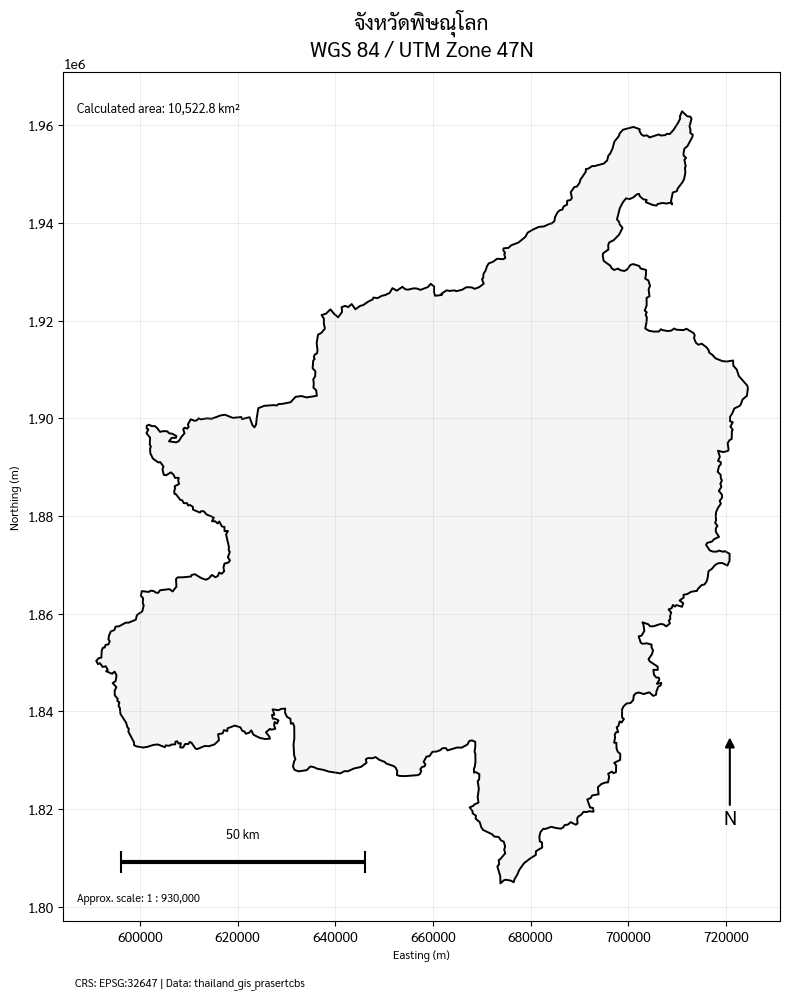

In [39]:
fig, ax = plt.subplots(
    figsize=(8, 10)
)

phs_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="black",
    linewidth=1.4
)

ax.set_title(
    "จังหวัดพิษณุโลก\nWGS 84 / UTM Zone 47N",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(
    alpha=0.25,
    linewidth=0.6
)

add_north_arrow(ax)
add_projected_scalebar(ax)

scale_n = approximate_numeric_scale(
    fig,
    ax
)

if scale_n:
    ax.text(
        0.02,
        0.02,
        f"Approx. scale: 1 : {scale_n:,}",
        transform=ax.transAxes,
        fontsize=8,
        va="bottom"
    )

ax.text(
    0.02,
    0.965,
    f"Calculated area: {area_phs:,.1f} km²",
    transform=ax.transAxes,
    fontsize=9,
    va="top"
)

fig.text(
    0.10,
    0.02,
    "CRS: EPSG:32647 | Data: thailand_gis_prasertcbs",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

## 36. Export publication map เป็น PNG 300 dpi

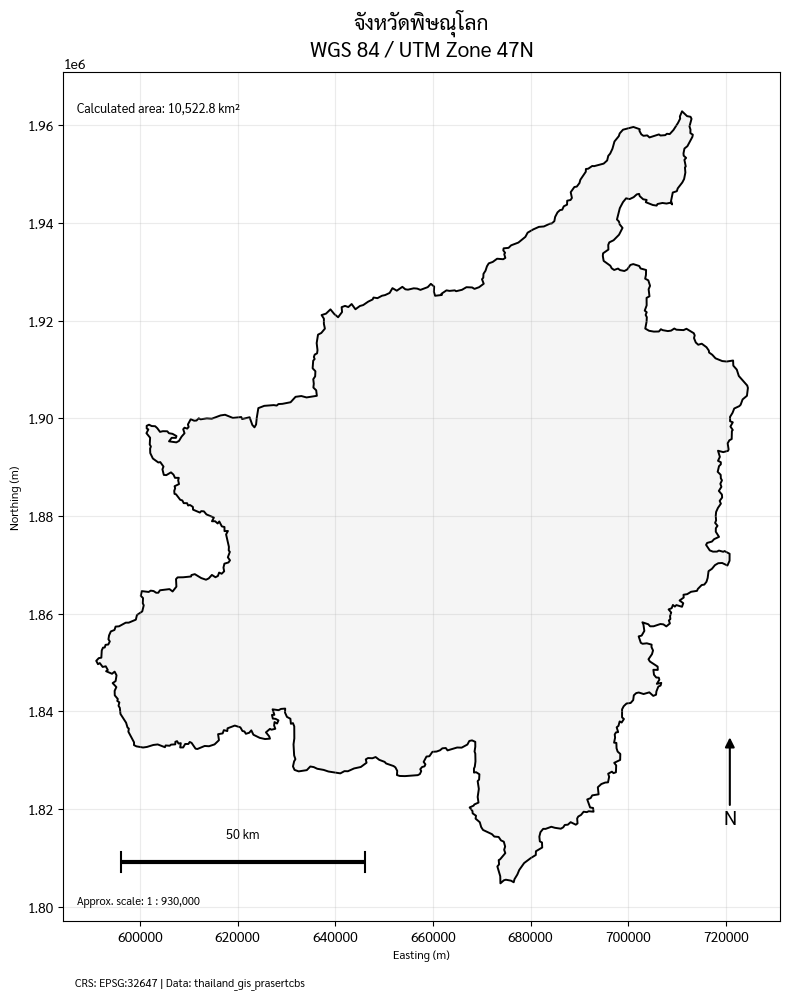

Saved: /content/gis02_outputs/maps/phitsanulok_utm47_map_300dpi.png


In [40]:
maps_dir = OUTPUT_DIR / "maps"
maps_dir.mkdir(
    parents=True,
    exist_ok=True
)

png_path = (
    maps_dir
    / "phitsanulok_utm47_map_300dpi.png"
)

fig, ax = plt.subplots(
    figsize=(8, 10)
)

phs_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="black",
    linewidth=1.4
)

ax.set_title(
    "จังหวัดพิษณุโลก\nWGS 84 / UTM Zone 47N",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.25)

add_north_arrow(ax)
add_projected_scalebar(ax)

scale_n = approximate_numeric_scale(
    fig,
    ax
)

if scale_n:
    ax.text(
        0.02,
        0.02,
        f"Approx. scale: 1 : {scale_n:,}",
        transform=ax.transAxes,
        fontsize=8
    )

ax.text(
    0.02,
    0.965,
    f"Calculated area: {area_phs:,.1f} km²",
    transform=ax.transAxes,
    fontsize=9,
    va="top"
)

fig.text(
    0.10,
    0.02,
    "CRS: EPSG:32647 | Data: thailand_gis_prasertcbs",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_path)

# Part K — แสดงผลใน Folium

## 37. Analysis CRS → Display CRS

เราคำนวณพื้นที่ใน EPSG:32647 แล้ว  
ก่อนแสดงใน Folium เราแปลงกลับเป็น EPSG:4326

```text
EPSG:32647
Analysis
↓
to_crs(4326)
↓
Folium
Display
```

In [41]:
phs_web = phs_utm.to_crs(
    "EPSG:4326"
)

center = (
    phs_web.geometry
    .representative_point()
    .iloc[0]
)

m = folium.Map(
    location=[
        center.y,
        center.x
    ],
    zoom_start=8,
    tiles=None,
    control_scale=True
)

basemap = xyz.OpenTopoMap

folium.TileLayer(
    tiles=basemap.build_url(),
    attr=basemap.html_attribution,
    name="OpenTopoMap",
    overlay=False,
    control=True,
    show=True
).add_to(m)

folium.GeoJson(
    phs_web,
    name="Phitsanulok Province",
    style_function=lambda feature: {
        "fillColor": "#f4b183",
        "color": "#222222",
        "weight": 2,
        "fillOpacity": 0.55
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            adm1_th_col
            if adm1_th_col
            else adm1_en_col
        ],
        aliases=[
            "Province:"
        ]
    )
).add_to(m)

folium.LayerControl(
    collapsed=False
).add_to(m)

m

## 38. Export จังหวัดพิษณุโลกใน EPSG:32647

เราจะ export ทั้ง GeoPackage และ Shapefile ZIP  
เพื่อเปิดตรวจ CRS ใน QGIS

In [42]:
vector_dir = OUTPUT_DIR / "vectors"
vector_dir.mkdir(
    parents=True,
    exist_ok=True
)

gpkg_path = (
    vector_dir
    / "phitsanulok_utm47.gpkg"
)

if gpkg_path.exists():
    gpkg_path.unlink()

phs_utm.to_file(
    gpkg_path,
    layer="phitsanulok",
    driver="GPKG"
)

shp_folder = (
    vector_dir
    / "phitsanulok_utm47"
)

if shp_folder.exists():
    shutil.rmtree(
        shp_folder
    )

shp_folder.mkdir(
    parents=True,
    exist_ok=True
)

shp_path = (
    shp_folder
    / "phitsanulok_utm47.shp"
)

phs_utm.to_file(
    shp_path,
    driver="ESRI Shapefile",
    encoding="UTF-8"
)

zip_path = shutil.make_archive(
    str(
        vector_dir
        / "phitsanulok_utm47"
    ),
    "zip",
    root_dir=shp_folder
)

print("GeoPackage:", gpkg_path)
print("Shapefile ZIP:", zip_path)

GeoPackage: /content/gis02_outputs/vectors/phitsanulok_utm47.gpkg
Shapefile ZIP: /content/gis02_outputs/vectors/phitsanulok_utm47.zip


In [43]:
html_dir = OUTPUT_DIR / "html"
html_dir.mkdir(
    parents=True,
    exist_ok=True
)

html_path = (
    html_dir
    / "phitsanulok_crs_interactive.html"
)

m.save(html_path)

print("Saved:", html_path)

Saved: /content/gis02_outputs/html/phitsanulok_crs_interactive.html


## 39. ตรวจ outputs

In [44]:
for p in sorted(
    OUTPUT_DIR.rglob("*")
):
    if p.is_file():
        print(
            p.relative_to(
                OUTPUT_DIR
            ),
            f"({p.stat().st_size/1024:,.1f} KB)"
        )

html/phitsanulok_crs_interactive.html (39.2 KB)
maps/phitsanulok_utm47_map_300dpi.png (298.7 KB)
vectors/phitsanulok_utm47/phitsanulok_utm47.cpg (0.0 KB)
vectors/phitsanulok_utm47/phitsanulok_utm47.dbf (1.7 KB)
vectors/phitsanulok_utm47/phitsanulok_utm47.prj (0.4 KB)
vectors/phitsanulok_utm47/phitsanulok_utm47.shp (12.3 KB)
vectors/phitsanulok_utm47/phitsanulok_utm47.shx (0.1 KB)
vectors/phitsanulok_utm47.gpkg (108.0 KB)
vectors/phitsanulok_utm47.zip (12.3 KB)


# Concept Check

ลองตอบโดยไม่ย้อนดู code

1. CRS บอกอะไรเรา?
2. Geographic CRS ต่างจาก Projected CRS อย่างไร?
3. `set_crs()` ต่างจาก `to_crs()` อย่างไร?
4. เหตุใด degree จึงไม่ใช่ระยะทางคงที่?
5. เหตุใด EPSG:3857 ไม่เหมาะกับการเปรียบเทียบพื้นที่?
6. Equal-area projection เหมาะกับคำถามประเภทใด?
7. ทำไมพิษณุโลกใช้ EPSG:32647 สำหรับ local analysis?
8. Analysis CRS และ Display CRS จำเป็นต้องเหมือนกันหรือไม่?
9. Numeric scale ต่างจาก scale bar อย่างไร?
10. 300 dpi บอกอะไร และไม่ได้บอกอะไร?

# Exercise 1 — CRS Detective

จับคู่ CRS กับงานต่อไปนี้

| CRS | งาน |
|---|---|
| EPSG:4326 | ? |
| EPSG:3857 | ? |
| EPSG:6933 | ? |
| EPSG:32647 | ? |

ตัวเลือก:

```text
A. Web display ecosystem
B. Longitude / Latitude
C. Global area comparison
D. Phitsanulok distance / buffer
```

อธิบายเหตุผลของแต่ละข้อ ไม่ใช่ตอบแค่ตัวอักษร

# Exercise 2 — 1 degree ไม่เท่ากันทุก latitude

แก้ `latitudes` เป็น

```python
latitudes = [0, 10, 20, 30, 40, 50, 60]
```

แล้ว

1. คำนวณระยะทางของ longitude 1°
2. สร้างตาราง
3. สร้างกราฟ
4. อธิบายแนวโน้มด้วยคำพูดของตนเอง

> คำถาม: ทำไมระยะทางลดลงเมื่อ latitude สูงขึ้น?

# Exercise 3 — Projection Distortion

เลือก 3 ประเทศจาก latitude ที่ต่างกัน

ตัวอย่าง:

```text
Thailand
Canada
Greenland
```

คำนวณพื้นที่จาก

```text
EPSG:3857
EPSG:6933
```

แล้วคำนวณ

$$
Difference(\%)
=
rac{
A_{3857}-A_{6933}
}{
A_{6933}
}
	imes100
$$

ตอบ:

> ประเทศใดได้รับผลจาก Web Mercator area distortion มากที่สุด?

# Exercise 4 — Map Scale

กำหนดแผนที่

$$
1:100{,}000
$$

คำนวณ ground distance สำหรับ

- 1 cm
- 5 cm
- 12.5 cm

ใช้

$$
D_{ground}
=
D_{map}
\times
n
$$

แล้วแปลงหน่วยเป็น kilometer

# Exercise 5 — Phitsanulok Workflow

ทำ workflow นี้ด้วยตนเองอีกครั้งโดยไม่ copy ทั้ง cell

```text
Query Phitsanulok
↓
Check CRS
↓
to_crs(EPSG:32647)
↓
Calculate area
↓
Create publication map
↓
Export PNG 300 dpi
↓
Export GeoPackage
↓
Convert to EPSG:4326
↓
Display in Folium
```

เขียนคำอธิบาย 1–2 ประโยคใต้แต่ละขั้นว่า “ทำไมต้องทำ”

# MSc Challenge — Geodesic Area vs Projected Area

สำหรับผู้เรียน ป.โท ลองศึกษาการคำนวณพื้นที่แบบ geodesic ด้วย

```python
pyproj.Geod.geometry_area_perimeter()
```

แล้วเปรียบเทียบ

$$
A_{geodesic}
$$

กับ

$$
A_{projected}
$$

คำนวณ

$$
Difference(\%)
=
\frac{
A_{projected}-A_{geodesic}
}{
A_{geodesic}
}
\times100
$$

คำถาม:

> วิธีใดเหมาะกับงานของคุณ และเหตุใด?

ไม่จำเป็นต้องมีคำตอบเดียว เพราะคำตอบขึ้นกับ **พื้นที่ศึกษา ขนาดพื้นที่ และวัตถุประสงค์ของการวิเคราะห์**

# Summary

Notebook 02 เปลี่ยนจากการ “ดูแผนที่” ไปสู่การ “วัดบนแผนที่อย่างมีหลักการ”

แนวคิดที่ต้องจำ:

$$
\boxed{
\text{CRS}
\rightarrow
\text{Units}
\rightarrow
\text{Measurement}
}
$$

และ

$$
\boxed{
\text{Choose CRS based on the spatial question}
}
$$

### กฎง่าย ๆ สำหรับ course นี้

```text
Folium / location
→ EPSG:4326

World area comparison
→ Equal-area projection

Phitsanulok distance / buffer / local area
→ EPSG:32647
```

## ต่อไป: Notebook 03

**Thailand Provinces — Attribute Query, Area, Statistics & Choropleth**

คำถามเปิดบทถัดไป:

> เมื่อเราคำนวณพื้นที่ได้ถูกต้องแล้ว เราจะเปรียบเทียบพื้นที่ของจังหวัดทั้งประเทศ ทำสถิติ และสื่อสารด้วย choropleth map อย่างไร?